# Spacetime Crystal

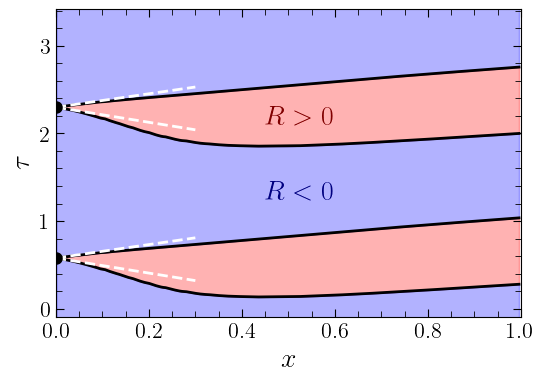

In [21]:
import numpy as np
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import ticker
from scipy.optimize import curve_fit
from pylab import *
from scipy import ndimage

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 16
    })

# low resolution
NEClines=np.loadtxt("NEClines.dat")
Delta=3.41853

# NEC angle lines
x=np.arange(0,0.4,0.1)
line1=0.577053 - 0.859563*x
line2=0.577053 + 0.769894*x
line3=2.29978 - 0.859563*x
line4=2.29978 + 0.769894*x
pause
# generating a figure
fig, ax=plt.subplots(sharex=True,facecolor='white',dpi=100,figsize=(6,4))
ax.set_xlim([0,1])
ax.set_ylim([-0.1,Delta])
ax.tick_params(which='major', direction='in',top="true",right="true",length=6)
ax.tick_params(which='minor', direction='in',top="true",right="true",length=4)
ax.minorticks_on()
plt.xlabel(r'$x$', fontsize = 20)
plt.ylabel(r'$\tau$',fontsize =  20)


# NEC lines
plt.fill_between(NEClines[:,0],NEClines[:,1], 4, color='blue', alpha=0.3)
plt.fill_between(NEClines[:,0],NEClines[:,1], NEClines[:,2], color='red', alpha=0.3)
plt.fill_between(NEClines[:,0],NEClines[:,3], NEClines[:,4], color='red', alpha=0.3)
plt.fill_between(NEClines[:,0],NEClines[:,2], NEClines[:,3], color='blue', alpha=0.3)
plt.fill_between(NEClines[:,0],NEClines[:,4], -1, color='blue', alpha=0.3)
plt.plot(NEClines[:,0],NEClines[:,1],color="black",linestyle="-",linewidth=2,zorder=1,alpha=1)
plt.plot(NEClines[:,0],NEClines[:,2],color="black",linestyle="-",linewidth=2,zorder=1,alpha=1)
plt.plot(NEClines[:,0],NEClines[:,3],color="black",linestyle="-",linewidth=2,zorder=1,alpha=1)
plt.plot(NEClines[:,0],NEClines[:,4],color="black",linestyle="-",linewidth=2,zorder=1,alpha=1)

# NEC angle
plt.plot(x,line1,color="white",linestyle="--",linewidth=2,zorder=1,alpha=1)
plt.plot(x,line2,color="white",linestyle="--",linewidth=2,zorder=1,alpha=1)
plt.plot(x,line3,color="white",linestyle="--",linewidth=2,zorder=1,alpha=1)
plt.plot(x,line4,color="white",linestyle="--",linewidth=2,zorder=1,alpha=1)

#plt.plot(x,fit,color="black",linestyle=":",linewidth=2,zorder=1,alpha=0.5,label=r"$\rm extrapolation$")

# critical D
plt.plot(NEClines[0,0],NEClines[0,1],'o',color="black",markersize=8,alpha=1,zorder=1)
plt.plot(NEClines[0,0],NEClines[0,3],'o',color="black",markersize=8,alpha=1,zorder=1)

# D=4
#plt.plot(NEClines[3,0],NEClines[3,1],'o',color="black")

# labels
plt.text(0.45,1.25,r'$R<0$',fontsize=20, color=(0, 0, 0.5))
plt.text(0.45,2.1,r'$R>0$',fontsize=20, color=(0.5, 0, 0))

plt.savefig("Ricci4D.pdf",dpi=100,bbox_inches='tight')

[   0.            0.         -205.20537991]


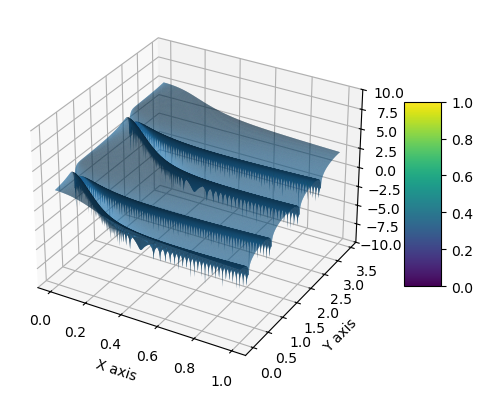

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Example input: list of triples (x, y, z)
data = np.loadtxt('R4d.dat')# Replace with your file name

# Convert list of triples to numpy array for easier manipulation
data_array = np.array(data)
print(data_array[0])
X = data_array[:, 0]
T = data_array[:, 1]
Z = data_array[:, 2]

# Create a meshgrid for surface plotting
X_unique = np.unique(X)
T_unique = np.unique(T)

X_grid, T_grid = np.meshgrid(X_unique, T_unique)
Z_grid = np.zeros(X_grid.shape)

# Populate Z_grid with corresponding Z values
for i in range(len(data)):
    x_index = np.where(X_unique == X[i])[0][0]
    t_index = np.where(T_unique == T[i])[0][0]
    Z_grid[t_index, x_index] = Z[i]

# Define z-axis limits
z_min, z_max = -10, 10  # Specify the z-axis range

# Create a masked array for Z values that exceed limits
Z_masked = np.where((Z_grid < z_min) | (Z_grid > z_max), np.nan, Z_grid)
Z_logabs = np.log10(np.abs(Z_grid))

# Create a figure and a 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with the masked values
surf = ax.plot_surface(X_grid, T_grid, Z_logabs, edgecolor='none',rstride=1,cstride=1)

# Plot the grey surface for out-of-bounds values
#ax.plot_surface(X_grid, T_grid, Z_grid, where=((Z_grid >= z_min) & (Z_grid <= z_max)), color='grey', alpha=0.5)

# Set z-axis limits
ax.set_zlim(z_min, z_max)

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# Set labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')

# Show the plot
plt.show()

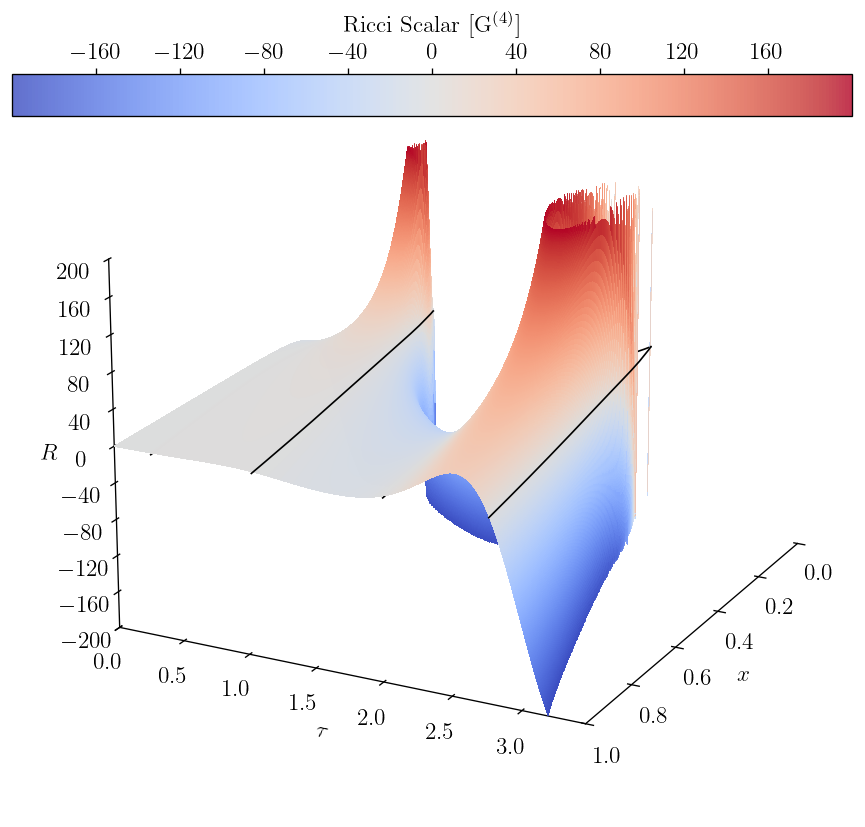

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import BoundaryNorm
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 14
    })


# Load line data from a separate file where columns represent x, y, and z values
branch1 = np.loadtxt('branch1.dat')
branch2 = np.loadtxt('branch2.dat')
branch3 = np.loadtxt('branch3.dat')
branch4 = np.loadtxt('branch4.dat')

# Load data from file where columns represent x, y, and z values
# Adjust delimiter as needed based on file format (e.g., ',' for CSV, space/tab for txt)

data = np.loadtxt('R4d.dat')  # Replace with your file name
x, y, z = data[:, 0], data[:, 1], data[:, 2]
for i in range(np.size(z)):
    if np.abs(z[i]) > 200: z[i] = np.nan
# Reshape x, y, and z data for 3D plotting if data is gridded (requires knowledge of grid shape)
# Here we assume the data forms a regular grid, e.g., (100, 100)
# Replace 100, 100 with the actual grid shape if known
grid_shape = (1601,801)  # Example grid shape, modify as needed
X = x.reshape(grid_shape)
Y = y.reshape(grid_shape)
Z = z.reshape(grid_shape)


# Clip the Z values to be within a specified range
#Z_clipped =  gaussian_filter(np.clip(Z, -120, 120),sigma=2)
Z_clipped =  Z

#Z_clipped = Z
# Create figure and 3D axis
fig = plt.figure(figsize=(16, 10), dpi=120)
ax = fig.add_subplot(111, projection='3d')

# Define discrete levels for color mapping
levels = np.linspace(-200, 200, 11)

cmap = plt.get_cmap("coolwarm")
#norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Plot the high-resolution 3D surface with lighting and improved colormap
#surface = ax.plot_surface(X, Y, Z_clipped, cmap="jet", rstride=1, cstride=1, alpha=1, norm=norm, edgecolor="none", shade=True)
#ax.plot_wireframe(X,Y,Z_clipped,rstride=20,cstride=20,edgecolors='grey',lw=0.5)

#ax.plot_surface(X, Y, Z_clipped, cmap="coolwarm", rstride=20, cstride=20, alpha=1, edgecolors='black', lw=0.5, shade=True)
# Set plot ranges
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 3.45)
ax.set_zlim(-200,200)

ax.plot(branch1[:,0], branch1[:,1], -2, color="black", linewidth=1,zorder=3)
ax.plot(branch2[:,0], branch2[:,1], -2, color="black", linewidth=1,zorder=1)
ax.plot(branch3[:,0], branch3[:,1], -2, color="black", linewidth=1,zorder=3)
ax.plot(branch4[:,0], branch4[:,1], -2, color="black", linewidth=1,zorder=1)

surface = ax.plot_surface(X, Y, Z_clipped, cmap="coolwarm", rstride=1, cstride=1, alpha=0.8, edgecolors='none', lw=0.5, shade=True, antialiased=False,zorder=2)


# Add lighting for a better visual effect
#ax.plot_surface(X, Y, Z_clipped, cmap="coolwarm", edgecolor="none", rstride=1, cstride=1, alpha=0.2, shade=True)

# Project the surface onto the x-y plane by setting Z to 0
#ax.contour(X, Y, Z_clipped, zdir='z', offset=-120, cmap="coolwarm",alpha=1, linewidths=2)

# Add color bar with label on top

# Create a color bar on top
#cbar = fig.colorbar(surface, ax=ax, shrink=0.5, aspect=10, pad=0.1, ticks=levels)
#cbar.set_label(r'$\rm Ricci~Scalar$', labelpad=15, rotation=0, loc='center')

# Create the horizontal color bar and position it on top of the plot
cbar = fig.colorbar(surface, ax=ax, orientation='horizontal', pad=0.1, fraction=0.04, ticks=levels)
cbar.set_label(r'$\rm Ricci~Scalar~[G^{(4)}]$', labelpad=6)
cbar.ax.xaxis.set_label_position('top')  # Move label to the top
cbar.ax.xaxis.set_ticks_position('top') 

# Manually adjust color bar position to center it horizontally
cbar.ax.set_position([0.05, 0.8, 0.9, 0.035]) 

# Remove mesh lines from the panes
ax.xaxis.pane.set_edgecolor('none')  # Remove mesh lines on xz plane
ax.yaxis.pane.set_edgecolor('none')  # Remove mesh lines on yz plane
ax.zaxis.pane.set_edgecolor('none')  # Remove mesh lines on xy plane if desired

ax.xaxis.pane.fill = False  # Disable background color for xz plane
ax.yaxis.pane.fill = False  # Disable background color for yz plane
ax.zaxis.pane.fill = False  # Disable background color for xy plane if desired
ax.grid(False)

# Enable major and minor ticks on each axis
ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.zaxis.set_major_locator(plt.MultipleLocator(40))

#ax.xaxis.set_minor_locator(AutoMinorLocator(5))  # Add 5 minor ticks between each major tick on x-axis
#ax.yaxis.set_minor_locator(AutoMinorLocator(5))  # Add 5 minor ticks between each major tick on y-axis
#ax.zaxis.set_minor_locator(AutoMinorLocator(5))  # Add 5 minor ticks between each major tick on z-axis

# Set tick parameters: make minor ticks shorter than major ticks
ax.tick_params(axis='both', which='major', length=7, width=1.5)  # Major ticks: longer and thicker
#ax.tick_params(axis='both', which='minor', length=4, width=1)    # Minor ticks: shorter and thinner

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\tau$')
#ax.set_zlabel(r'$R$')

# Adjust the z-axis label to appear at the top
ax.set_zlabel(r'$R$', labelpad=1)  # Increase labelpad to push it up
ax.zaxis.label.set_rotation(0)  # Set label rotation to 0 for vertical alignment
ax.zaxis.label.set_va('bottom')  # Align label at the bottom of the text box (top of the axis)

# Change the viewing angle so that negative x-values are on the left
#ax.view_init(elev=40, azim=-40)  # Adjust elev and azim as needed
ax.view_init(elev=20, azim=27)  # Adjust elev and azim as needed
#plt.show()
# Show the plot
#plt.tight_layout()
#fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.85)  # Adjust these values as needed
plt.savefig("Ricci4D.png",dpi=200,bbox_inches='tight')

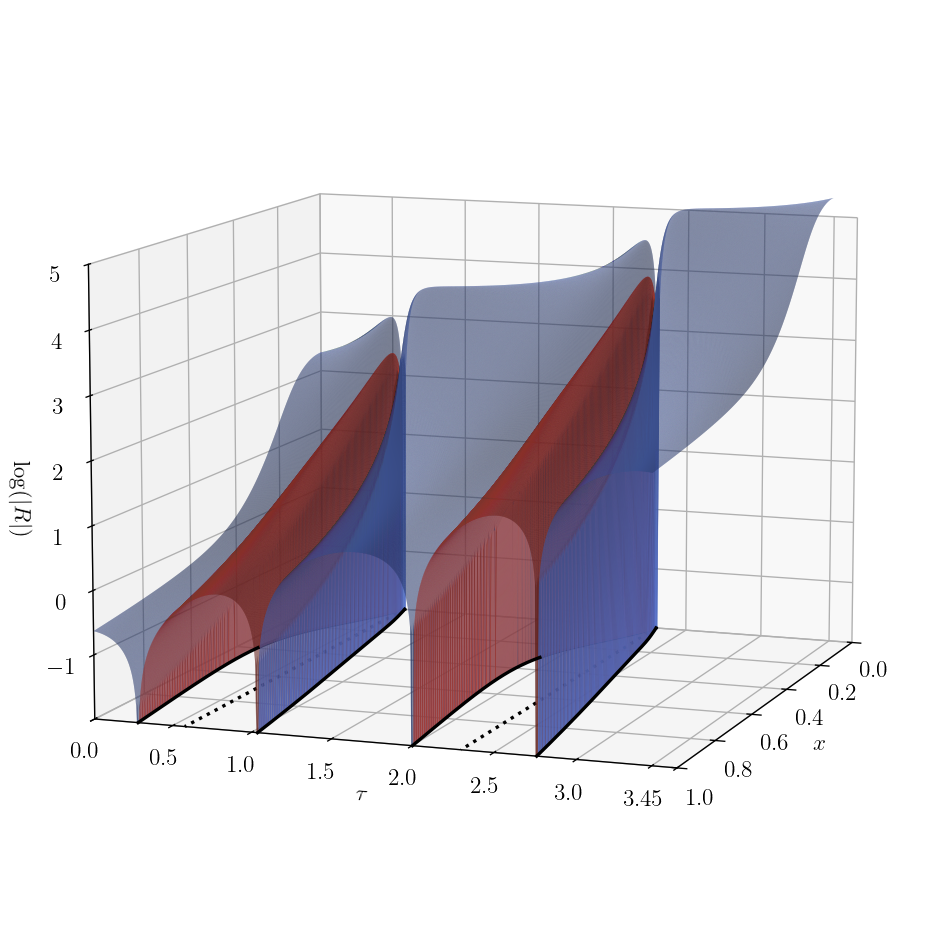

In [24]:
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 14
    })

# Example input: list of quadruples (x, y, z, sgn)
data = np.loadtxt('logabsR.dat')

branch1 = np.loadtxt('unec_low.dat')
branch2 = np.loadtxt('vnec_low.dat')
branch3 = np.loadtxt('unec_high.dat')
branch4 = np.loadtxt('vnec_high.dat')

#NEC vertex
tau0=0.577053
Delta=3.445

# Convert list of quadruples to numpy array for easier manipulation
data_array = np.array(data)
X = data_array[:, 0]
Y = data_array[:, 1]
Z = data_array[:, 2]
sgn = data_array[:, 3]

# Create a grid for X and Y
X_unique = np.unique(X)
Y_unique = np.unique(Y)
X_grid, Y_grid = np.meshgrid(X_unique, Y_unique)

# Create a grid for Z values
Z_grid = np.full(X_grid.shape, np.nan)  # Use NaN for missing values
color_grid = np.full(X_grid.shape, np.nan)  # Create a grid for colors

# Populate Z_grid and color_grid based on the (x, y) coordinates
for i in range(len(data_array)):
    x_index = np.where(X_unique == X[i])[0][0]
    y_index = np.where(Y_unique == Y[i])[0][0]
    Z_grid[y_index, x_index] = Z[i]
    color_grid[y_index, x_index] = sgn[i]  # Store the sign for color mapping

# Define custom colors using hex codes
positive_color = '#d0483e'  # Hex code for positive color (blue)
negative_color = '#6283e9'  # Hex code for negative color (red)
 
# Create a colormap using custom colors
cmap = cm.colors.ListedColormap([negative_color, positive_color])

# Normalize colors for the surface
norm = plt.Normalize(vmin=-1, vmax=1)  # Normalization for color mapping

# Create a figure and a 3D axis
fig = plt.figure(figsize=(16, 10), dpi=120)
ax = fig.add_subplot(111, projection='3d')

#Axes limits
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 3.6)
ax.set_zlim(-2,5)

#Set axes ticks manually
ax.set_xticks([0.00,0.2,0.4,0.6,0.8,1.0])
ax.set_xticklabels([r'$0.0$',r'$0.2$',r'$0.4$',r'$0.6$',r'$0.8$',r'$1.0$'])
ax.set_yticks([0.00,0.5,1,1.5,2,2.5,3,3.45,3.6])
ax.set_yticklabels([r'$0.0$',r'$0.5$',r'$1.0$',r'$1.5$',r'$2.0$',r'$2.5$',r'$3.0$',r'$3.45$',''])
ax.set_zticks([-2,-1,0,1,2,3,4,5])
ax.set_zticklabels(['',r'$-1$',r'$0$',r'$1$',r'$2$',r'$3$',r'$4$',r'$5$'])

#Plot NEC curves
ax.plot(branch1[:,0], branch1[:,1], -2, color="black", linewidth=2,zorder=3)
ax.plot(branch2[:118,0], branch2[:118,1], -2, color="black", linewidth=2,zorder=1)
ax.plot(branch2[119:,0], branch2[119:,1], -2, color="black", linewidth=2,zorder=3)
ax.plot(branch3[:,0], branch3[:,1], -2, color="black", linewidth=2,zorder=3)
ax.plot(branch4[:90,0], branch4[:90,1], -2, color="black", linewidth=2,zorder=1)
ax.plot(branch4[91:,0], branch4[91:,1], -2, color="black", linewidth=2,zorder=3)

#Plot NEC vertex lines
ax.plot([0,1],[tau0,tau0],[-2,-2],color='black', linestyle=':', linewidth=2,zorder=1,alpha=1)
ax.plot([0,1],[tau0+Delta/2,tau0+Delta/2],[-2,-2],color='black', linestyle=':', linewidth=2,zorder=1,alpha=1)

# Plot the surface using the custom colormap
surf = ax.plot_surface(X_grid, Y_grid, Z_grid, facecolors=cmap(norm(color_grid)), rstride=1, cstride=1, antialiased=True, linewidth=0, alpha=0.8,zorder=2)

# Remove mesh lines from the panes
#ax.xaxis.pane.set_edgecolor('none')  # Remove mesh lines on xz plane
#ax.yaxis.pane.set_edgecolor('none')  # Remove mesh lines on yz plane
#ax.zaxis.pane.set_edgecolor('none')  # Remove mesh lines on xy plane if desired

#ax.xaxis.pane.fill = False  # Disable background color for xz plane
#ax.yaxis.pane.fill = False  # Disable background color for yz plane
#ax.zaxis.pane.fill = False  # Disable background color for xy plane if desired
#ax.grid(False)

# Set labels
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\tau$')
ax.set_zlabel(r'$\log(|R|)$')

# Show color bar (optional)
#sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#sm.set_array([])
#fig.colorbar(sm, ax=ax, shrink=0.5, aspect=5, label='Sign (1 = Positive, -1 = Negative)')

ax.view_init(elev=10, azim=20)
# Show the plot
#plt.savefig("logR_3d.pdf",dpi=200,bbox_inches='tight')
plt.savefig("logR_3d.png",dpi=200,bbox_inches='tight')
#plt.show()

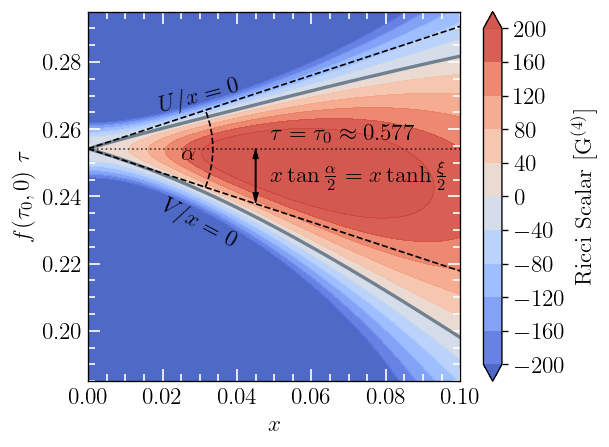

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, MaxNLocator
import matplotlib.colors as mcolors
from matplotlib import patches

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 14
    })


# NEC saturation lines
branch1 = np.loadtxt('unec_high.dat')
branch2 = np.loadtxt('vnec_high.dat')
branch3 = np.loadtxt('unec_low.dat')
branch4 = np.loadtxt('vnec_low.dat')

# loading data for Ricci scalar
data = np.loadtxt('R4d_cont.dat')

# constants
f0=0.440516
tau0=0.577033
alpha=40
scale=f0

# rescaling of tau
x, y, z = data[:, 0], f0*data[:, 1], data[:, 2]

# reshaping the grid
grid_shape = (401,401)
X = x.reshape(grid_shape)
Y = y.reshape(grid_shape)
Z = z.reshape(grid_shape)

# Clip z-values and Gaussian smoothing
#Z_clipped =  gaussian_filter(np.clip(Z, -120, 120),sigma=2)
Z_clipped = Z

# Create the 2D contour plot
fig, ax = plt.subplots(figsize=(5, 4),dpi=120)


#xticks = (0.001,0.02,0.039,0.058,0.077,0.1)
#xlabels = (r'$0.0$',r'$0.02$',r'$0.04$',r'$0.06$',r'$0.08$',r'$0.1$')
#ax.set_xticks(xticks, labels=xlabels)


# Plot contour lines
#contour = ax.contour(X, Y, Z_clipped, levels=levels, cmap="jet")
ax.plot(branch1[:,0], scale*branch1[:,1], color="slategrey", linewidth=2,zorder=2)
ax.plot(branch2[:,0], scale*branch2[:,1], color="slategrey", linewidth=2,zorder=2)
ax.plot(branch3[:,0], scale*branch3[:,1], color="slategrey", linewidth=2,zorder=2)
ax.plot(branch4[:,0], scale*branch4[:,1], color="slategrey", linewidth=2,zorder=2)

# Set plot ranges
ax.set_xlim(0.00, 0.1)
ax.set_ylim(0.185, 0.295)

# Enable minor ticks
ax.minorticks_on()

# Customize minor tick parameters (optional)
ax.tick_params(axis='both', which='both', direction='in', width=1)
ax.tick_params(which='both', direction='in', width=1, top=True, right=True)
ax.tick_params(which='major', length=7, color='white')
ax.tick_params(which='minor', length=4, color='white')

# Define discrete levels for color mapping
levels = np.linspace(-200, 200, 11)

# Define a colormap with extended colors
cmap = plt.get_cmap("coolwarm", len(levels)+1)
cmap = cmap(np.linspace(0, 1, cmap.N))
open_cmap = ListedColormap(cmap)

# Set colors for "under" and "over" values
open_cmap.set_under('#3B59C0')  # Color for values below the lowest level
open_cmap.set_over('#cf463d')     # Color for values above the highest level

# BoundaryNorm for color mapping
norm = BoundaryNorm(levels, open_cmap.N, extend='both')

# Add filled contours with the extended colormap
contourf = ax.contourf(X, Y, Z_clipped, levels=levels, cmap=open_cmap, extend='both', norm=norm, alpha=0.9)

# some text labels
ax.text(0.025,0.251,r'$\alpha$', color="black", fontsize=14)
ax.text(0.03, 0.27,r'$U/x=0$', color="black", fontsize=14, rotation=15, ha='center', va='center')
ax.text(0.03, 0.232,r'$V/x=0$', color="black", fontsize=14, rotation=-28, ha='center', va='center')
ax.text(0.049, 0.257, r'$\tau=\tau_0\approx 0.577$', color="black", fontsize=14)

# NEC angle lines
x=np.arange(0,0.4,0.1)

line1=f0*tau0 - np.tan(pi*alpha/2/180)*x 
line2=f0*tau0 + np.tan(pi*alpha/2/180)*x 

# Define the arc parameters
center = (0, f0*tau0)        # Center of the arc
width = 0.067              # Width of the arc
height = 0.067             # Height of the arc (same as width for a circular arc)
theta1 = -alpha/2            # Start angle of the arc in degrees
theta2 = alpha/2           # End angle of the arc in degrees

# Create the arc
arc = patches.Arc(center, width=width, height=height, theta1=theta1, theta2=theta2, color='black',linestyle="--", linewidth=1,zorder=4)

# Add the arc to the plot
ax.add_patch(arc)

# add two-headed arrow
plt.arrow(0.045, f0*tau0, 0, -0.81*0.045*f0, width=0.0002, head_width=0.0015, head_length=0.003, linewidth=0.5, color='black', length_includes_head=True)
plt.arrow(0.045, f0*tau0-0.81*0.045*f0, 0, 0.81*0.045*f0, width=0.0002, head_width=0.0015, head_length=0.003, linewidth=0.5, color='black', length_includes_head=True)


#plt.plot([0.05,0.05],[f0*tau0,f0*tau0-0.75*0.05*f0],color="black",linestyle="-",linewidth=1,zorder=3,alpha=1)
ax.text(0.049, f0*tau0-0.9*0.025*f0, r'$x\tan\frac{\alpha}{2}=x\tanh\frac{\xi}{2} $', color="black", fontsize=14)


# NEC angle
plt.plot(x,line1,color="black",linestyle="--",linewidth=1,zorder=3,alpha=1)
plt.plot(x,line2,color="black",linestyle="--",linewidth=1,zorder=3,alpha=1)

#\tau = \tau_0 line
ax.axhline(y=scale*branch3[0,1], color='black', linestyle=':', linewidth=1,zorder=2,alpha=0.7)

# Add a color bar
cbar = fig.colorbar(contourf, ax=ax, extend='both', ticks=levels)
cbar.set_label(r'$\rm Ricci~Scalar~[G^{(4)}]$', labelpad=3)

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$f(\tau_0,0)~\tau$')

#ax.annotate(r'$0.00$', xy=(62, 43), xycoords='figure pixels')

plt.savefig("NECanglenew.pdf",dpi=200,bbox_inches='tight')

#plt.show()


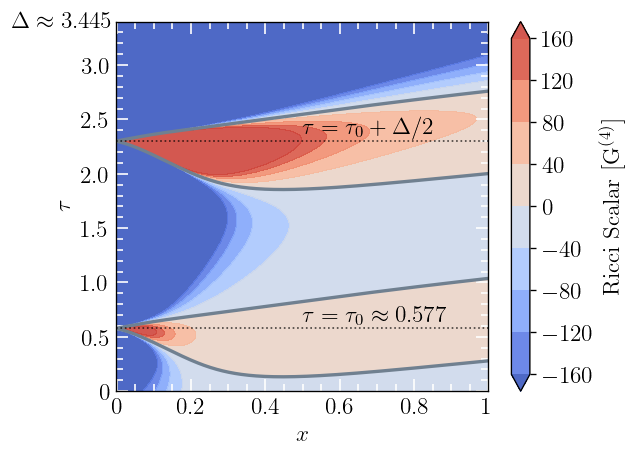

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, MaxNLocator
import matplotlib.colors as mcolors
from matplotlib import patches

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 14
    })


# NEC saturation lines
branch1 = np.loadtxt('unec_high.dat')
branch2 = np.loadtxt('unec_low.dat')
branch3 = np.loadtxt('vnec_high.dat')
branch4 = np.loadtxt('vnec_low.dat')

# loading data for Ricci scalar
data = np.loadtxt('R4d.dat')

# constants
f0=0.440516
f0=1
tau0=0.577053
#alpha=36.8699
alpha=40
scale=f0

# rescaling of tau
x, y, z = data[:, 0], f0*data[:, 1], data[:, 2]

# reshaping the grid
grid_shape = (1601,801)
X = x.reshape(grid_shape)
Y = y.reshape(grid_shape)
Z = z.reshape(grid_shape)

# Clip z-values and Gaussian smoothing
#Z_clipped =  gaussian_filter(np.clip(Z, -160, 160),sigma=0.5)
Z_clipped =  Z
# Define discrete levels for color mapping
levels = np.linspace(-160, 160, 9)

# Create the 2D contour plot
fig, ax = plt.subplots(figsize=(5, 4),dpi=120)

#Axes limits
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 3.4)

xticks = (0.001,0.201,0.401,0.601,0.801,1)
xlabels = (r'$0$',r'$0.2$',r'$0.4$',r'$0.6$',r'$0.8$',r'$1$')
ax.set_xticks(xticks, labels=xlabels)
#xticks = (0.001)
#xticks = (0.006,0.204,0.402,0.6,0.798,0.996)
#xlabels = (r'$0.0$')
#xlabels = (r'$0.0$',r'$0.2$',r'$0.4$',r'$0.6$',r'$0.8$',r'$1.0$')
#ax.set_xticks(xticks, labels=xlabels)

yticks = (0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.4)
ylabels = (r'$0$',r'$0.5$',r'$1.0$',r'$1.5$',r'$2.0$',r'$2.5$',r'$3.0$',r'')
ax.set_yticks(yticks, labels=ylabels)

# Plot contour lines
#contour = ax.contour(X, Y, Z_clipped, levels=levels, cmap="jet")
ax.plot(branch1[:,0], scale*branch1[:,1], color="slategrey", linewidth=2,zorder=2)
ax.plot(branch2[:,0], scale*branch2[:,1], color="slategrey", linewidth=2,zorder=2)
ax.plot(branch3[:,0], scale*branch3[:,1], color="slategrey", linewidth=2,zorder=2)
ax.plot(branch4[:,0], scale*branch4[:,1], color="slategrey", linewidth=2,zorder=2)

# Set plot ranges
#ax.set_xlim(0.001, 1)
#ax.set_ylim(0, f0* Delta)

# Enable minor ticks
ax.minorticks_on()

# Customize minor tick parameters (optional)
ax.tick_params(axis='both', which='both', direction='in', width=1)
ax.tick_params(which='both', direction='in', width=1, top=True, right=True)
ax.tick_params(which='major', length=7, color='white')
ax.tick_params(which='minor', length=4, color='white')


# Define a colormap with extended colors
cmap = plt.get_cmap("coolwarm", len(levels)+1)
cmap = cmap(np.linspace(0, 1, cmap.N))
open_cmap = ListedColormap(cmap)

# Set colors for "under" and "over" values
open_cmap.set_under('#3B59C0')  # Color for values below the lowest level
open_cmap.set_over('#cf463d')     # Color for values above the highest level

# BoundaryNorm for color mapping
norm = BoundaryNorm(levels, open_cmap.N, extend='both')

# Add filled contours with the extended colormap
contourf = ax.contourf(X, Y, Z_clipped, levels=levels, cmap=open_cmap, extend='both', norm=norm, alpha=0.9)
#ax.contour(X, Y, Z_clipped, levels=[0], colors="slategrey", linewidths=2)
#\tau = \tau_0 line
ax.axhline(y=scale*0.577, color='black', linestyle=':', linewidth=1,zorder=2,alpha=0.7)
ax.axhline(y=scale*0.577+3.445/2, color='black', linestyle=':', linewidth=1,zorder=2,alpha=0.7)

ax.text(0.5, 0.65, r'$\tau=\tau_0\approx 0.577$', color="black", fontsize=14)
ax.text(0.5, 2.37, r'$\tau=\tau_0+\Delta /2$', color="black", fontsize=14)

# Add a color bar
cbar = fig.colorbar(contourf, ax=ax, extend='both', ticks=levels)
cbar.set_label(r'$\rm Ricci~Scalar~[G^{(4)}]$', labelpad=3)

ax.text(-0.28, f0 * 3.4, r'$\Delta\approx 3.445$', transform=ax.get_yaxis_transform(), ha='left', va='center')

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\tau$')



plt.savefig("Fig2FE.pdf",dpi=200,bbox_inches='tight')

#plt.show()